In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data=pd.read_csv("household_energy_consumption.csv")

In [6]:
data.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2


In [7]:
data.shape

(90000, 7)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            90000 non-null  object 
 1   Date                    90000 non-null  object 
 2   Energy_Consumption_kWh  90000 non-null  float64
 3   Household_Size          90000 non-null  int64  
 4   Avg_Temperature_C       90000 non-null  float64
 5   Has_AC                  90000 non-null  object 
 6   Peak_Hours_Usage_kWh    90000 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 4.8+ MB


In [9]:
print(data.isnull().sum())

Household_ID              0
Date                      0
Energy_Consumption_kWh    0
Household_Size            0
Avg_Temperature_C         0
Has_AC                    0
Peak_Hours_Usage_kWh      0
dtype: int64


In [13]:
data.describe()

,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Peak_Hours_Usage_kWh
count,90000.000000,90000.000000,90000.000000,90000.000000
mean,10.571988,3.487811,17.505802,4.319557
std,5.519494,1.709761,2.491621,2.531432
min,0.500000,1.000000,10.000000,0.200000
25%,6.000000,2.000000,15.800000,2.300000
50%,10.400000,3.000000,17.500000,4.000000
75%,14.800000,5.000000,19.200000,6.000000
max,20.000000,6.000000,25.000000,10.000000


In [15]:
data.describe(include="object")

,Household_ID,Date,Has_AC
count,90000,90000,90000
unique,12857,8,2
top,H12857,2025-04-01,No
freq,8,12857,45508


In [17]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [18]:
for col in data.columns:
    print(f"\n{col}")
    print("Unique values:", data[col].nunique())


Household_ID
Unique values: 12857

Date
Unique values: 8

Energy_Consumption_kWh
Unique values: 196

Household_Size
Unique values: 6

Avg_Temperature_C
Unique values: 151

Has_AC
Unique values: 2

Peak_Hours_Usage_kWh
Unique values: 99


In [20]:
print("Number of households:", data["Household_ID"].nunique())

Number of households: 12857


In [22]:
data["Household_ID"].value_counts().head(20)

Household_ID
H12857    8
H08576    7
H08566    7
H08567    7
H08568    7
H08569    7
H08570    7
H08571    7
H08572    7
H08573    7
H08574    7
H08575    7
H08577    7
H08639    7
H08578    7
H08579    7
H08580    7
H08581    7
H08582    7
H08583    7
Name: count, dtype: int64

In [24]:
#data->object->datetime

data["Date"] = pd.to_datetime(data["Date"])


dtype('<M8[ns]')

In [25]:
data["Date"].dtype

dtype('<M8[ns]')

In [27]:
print("Minimum date:", data["Date"].min())
print("Maximum date:", data["Date"].max())

Minimum date: 2025-04-01 00:00:00
Maximum date: 2025-04-08 00:00:00


In [29]:
data["Date"].value_counts().sort_index()

Date
2025-04-01    12857
2025-04-02    12857
2025-04-03    12857
2025-04-04    12857
2025-04-05    12857
2025-04-06    12857
2025-04-07    12857
2025-04-08        1
Name: count, dtype: int64

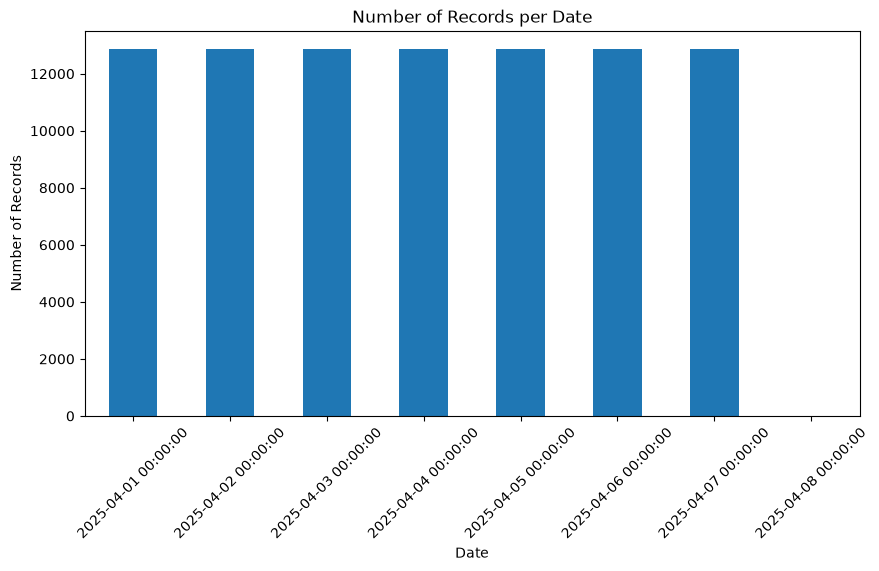

In [31]:
plt.figure(figsize=(10, 5))

data["Date"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Records per Date")
plt.xlabel("Date")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)
plt.show()

In [33]:
data["Energy_Consumption_kWh"].describe()

count    90000.000000
mean        10.571988
std          5.519494
min          0.500000
25%          6.000000
50%         10.400000
75%         14.800000
max         20.000000
Name: Energy_Consumption_kWh, dtype: float64

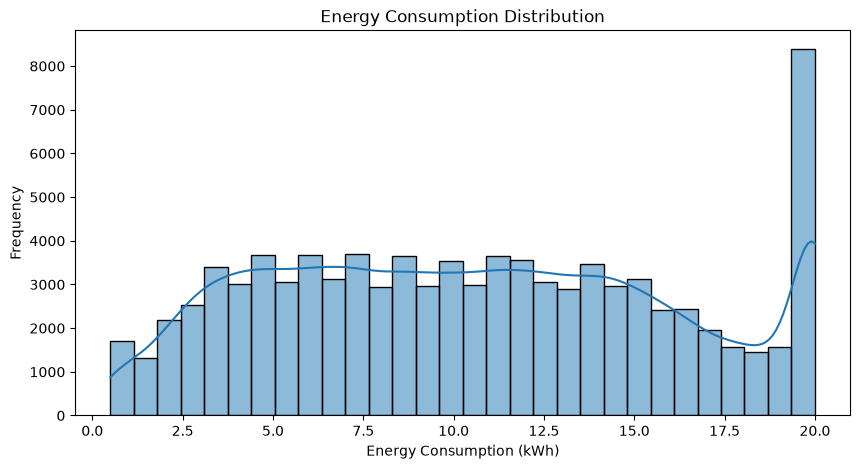

In [36]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data["Energy_Consumption_kWh"],
    bins=30,
    kde=True
)

plt.title("Energy Consumption Distribution")
plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("Frequency")

plt.show()

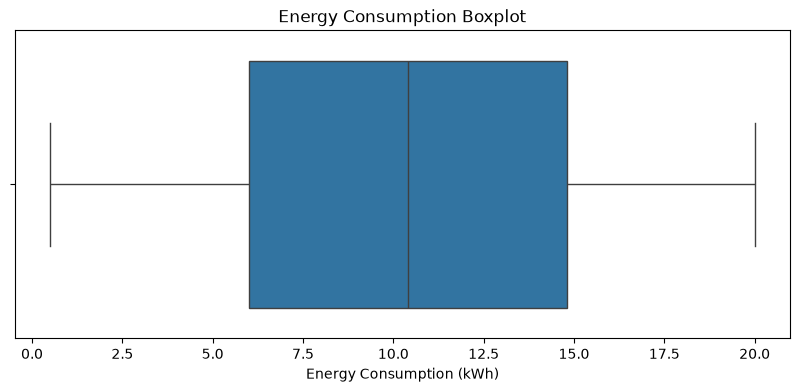

In [37]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=data["Energy_Consumption_kWh"]
)

plt.title("Energy Consumption Boxplot")
plt.xlabel("Energy Consumption (kWh)")

plt.show()

In [39]:
data["Household_Size"].value_counts().sort_index()

Household_Size
1    15260
2    15177
3    14651
4    14882
5    15372
6    14658
Name: count, dtype: int64

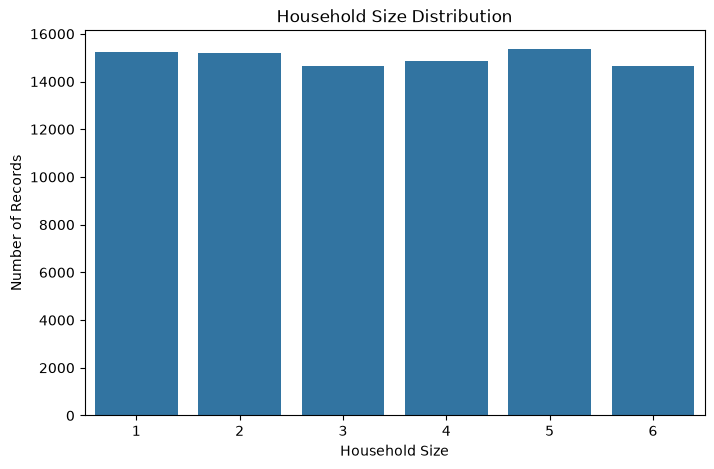

In [40]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Household_Size"
)

plt.title("Household Size Distribution")
plt.xlabel("Household Size")
plt.ylabel("Number of Records")

plt.show()

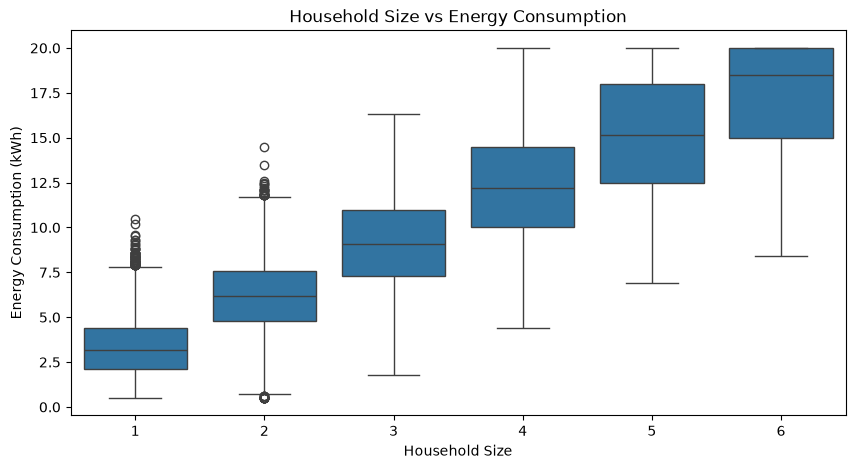

In [41]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=data,
    x="Household_Size",
    y="Energy_Consumption_kWh"
)

plt.title("Household Size vs Energy Consumption")
plt.xlabel("Household Size")
plt.ylabel("Energy Consumption (kWh)")

plt.show()

In [42]:
data["Has_AC"].value_counts()

Has_AC
No     45508
Yes    44492
Name: count, dtype: int64

In [43]:
data["Has_AC"].value_counts(normalize=True) * 100

Has_AC
No     50.564444
Yes    49.435556
Name: proportion, dtype: float64

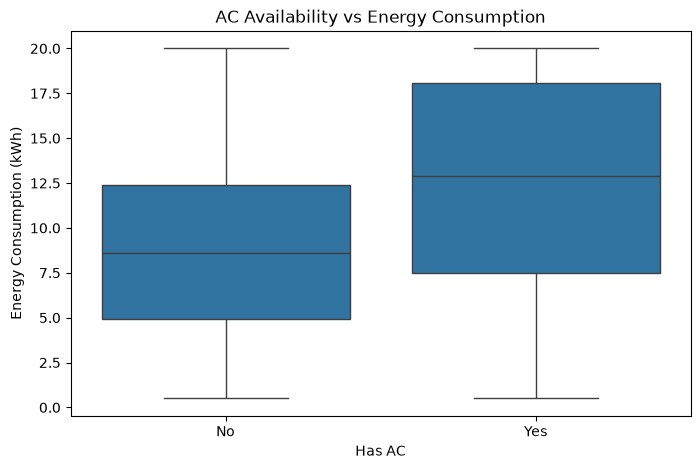

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="Has_AC",
    y="Energy_Consumption_kWh"
)

plt.title("AC Availability vs Energy Consumption")

plt.xlabel("Has AC")
plt.ylabel("Energy Consumption (kWh)")

plt.show()

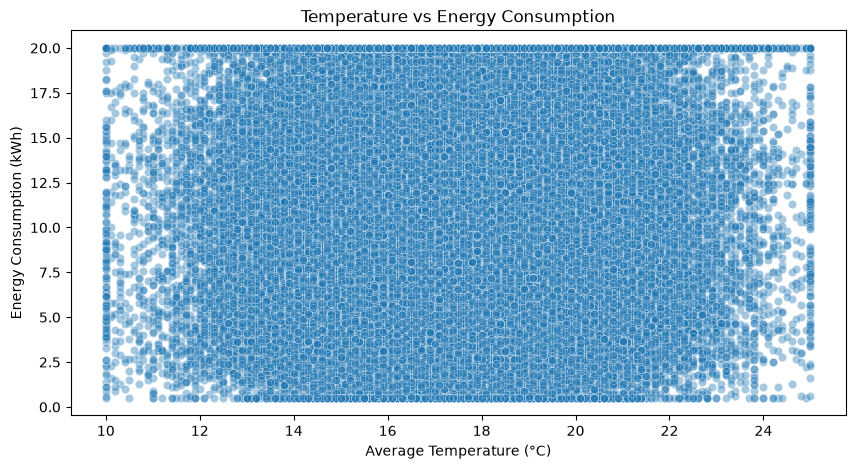

In [45]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=data,
    x="Avg_Temperature_C",
    y="Energy_Consumption_kWh",
    alpha=0.4
)

plt.title("Temperature vs Energy Consumption")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Energy Consumption (kWh)")

plt.show()

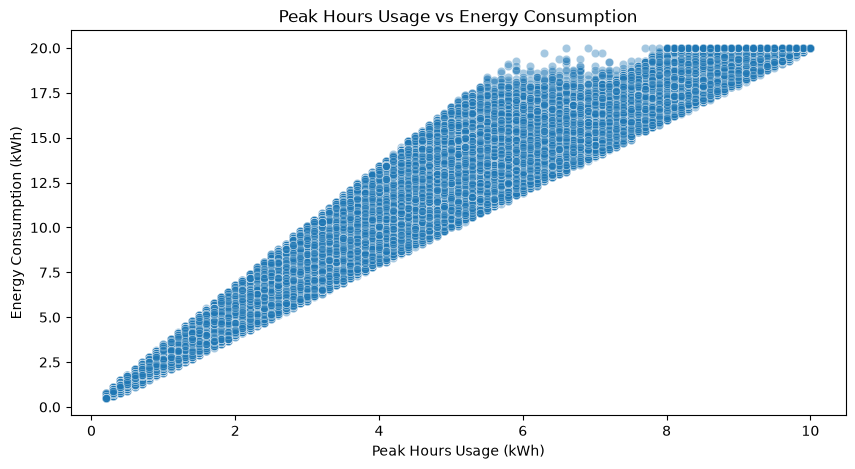

In [46]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=data,
    x="Peak_Hours_Usage_kWh",
    y="Energy_Consumption_kWh",
    alpha=0.4
)

plt.title("Peak Hours Usage vs Energy Consumption")
plt.xlabel("Peak Hours Usage (kWh)")
plt.ylabel("Energy Consumption (kWh)")

plt.show()

In [47]:
numeric_cols = [
    "Energy_Consumption_kWh",
    "Household_Size",
    "Avg_Temperature_C",
    "Peak_Hours_Usage_kWh"
]

corr = data[numeric_cols].corr()

corr

,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Peak_Hours_Usage_kWh
Energy_Consumption_kWh,1.000000,0.893959,0.033315,0.967641
Household_Size,0.893959,1.000000,0.001000,0.794549
Avg_Temperature_C,0.033315,0.001000,1.000000,0.031726
Peak_Hours_Usage_kWh,0.967641,0.794549,0.031726,1.000000


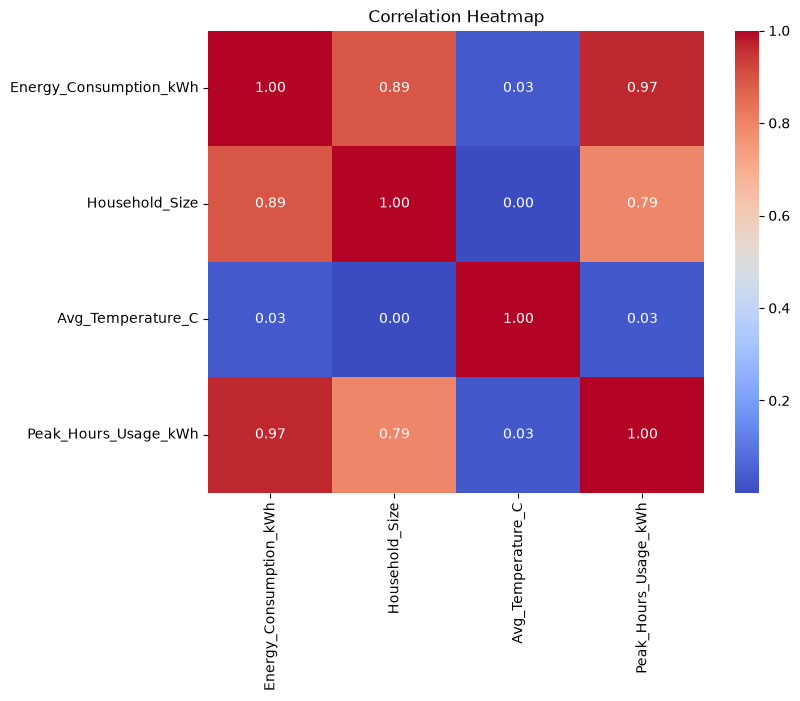

In [48]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [49]:
data.groupby("Has_AC")["Energy_Consumption_kWh"].agg(
    ["mean", "median", "std", "min", "max"]
)

,mean,median,std,min,max
Has_AC,,,,,
No,8.678663,8.6,4.492218,0.5,20.0
Yes,12.508548,12.9,5.793806,0.5,20.0


In [50]:
household_summary = data.groupby("Household_ID").agg(
    avg_energy=("Energy_Consumption_kWh", "mean"),
    avg_temperature=("Avg_Temperature_C", "mean"),
    avg_peak_usage=("Peak_Hours_Usage_kWh", "mean"),
    household_size=("Household_Size", "first"),
    has_ac=("Has_AC", "first")
)

household_summary.head()

,avg_energy,avg_temperature,avg_peak_usage,household_size,has_ac
Household_ID,,,,,
H00001,8.514286,16.742857,2.985714,4,No
H00002,12.485714,18.257143,4.500000,5,No
H00003,7.657143,16.828571,2.685714,3,No
H00004,17.971429,16.942857,8.085714,5,Yes
H00005,13.242857,18.000000,4.414286,5,No


In [51]:
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day
data["DayOfWeek"] = data["Date"].dt.dayofweek
data["IsWeekend"] = (data["DayOfWeek"] >= 5).astype(int)

In [52]:
data.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh,Year,Month,Day,DayOfWeek,IsWeekend
0,H00001,2025-04-01,8.4,4,17.8,No,3.2,2025,4,1,1,0
1,H00001,2025-04-02,7.9,4,17.3,No,2.8,2025,4,2,2,0
2,H00001,2025-04-03,9.2,4,18.6,No,3.0,2025,4,3,3,0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7,2025,4,4,4,0
4,H00001,2025-04-05,9.6,4,11.9,No,3.2,2025,4,5,5,1


In [58]:
from sklearn.model_selection import train_test_split

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [55]:
x = data[
    [
        "Household_Size",
        "Avg_Temperature_C",
        "Has_AC",
        "Peak_Hours_Usage_kWh",
        "Year",
        "Month",
        "Day",
        "DayOfWeek",
        "IsWeekend"
    ]
]

y = data["Energy_Consumption_kWh"]

In [57]:
print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (90000, 9)
y shape: (90000,)


In [60]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (72000, 9)
X_test: (18000, 9)
y_train: (72000,)
y_test: (18000,)


In [61]:
numeric_features = [
    "Household_Size",
    "Avg_Temperature_C",
    "Peak_Hours_Usage_kWh",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "IsWeekend"
]

categorical_features = [
    "Has_AC"
]

In [65]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numeric_features),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]
)

In [66]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Household_Size','Avg_Temperature_C','Has_AC',...,'Day','DayOfWeek', 'IsWeekend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset o

In [67]:
y_pred_linear = linear_model.predict(x_test)

In [68]:
def evaluate_model(model_name, y_true, y_pred):
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"Model: {model_name}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    
    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [71]:
results = []
result = evaluate_model(
    "Linear Regression",
    y_test,
    y_pred_linear
)

results.append(result)

Model: Linear Regression
MAE  : 0.6272
MSE  : 0.6231
RMSE : 0.7894
R²   : 0.9795


In [73]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(x_train, y_train)

y_pred_ridge = ridge_model.predict(x_test)

results.append(
    evaluate_model(
        "Ridge Regression",
        y_test,
        y_pred_ridge
    )
)

Model: Ridge Regression
MAE  : 0.6272
MSE  : 0.6231
RMSE : 0.7894
R²   : 0.9795


In [74]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf
    )
)

Model: Random Forest
MAE  : 0.5291
MSE  : 0.5228
RMSE : 0.7230
R²   : 0.9828


In [75]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        y_pred_gb
    )
)

Model: Gradient Boosting
MAE  : 0.4840
MSE  : 0.4161
RMSE : 0.6451
R²   : 0.9863


In [76]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="RMSE",
    ascending=True
)

,Model,MAE,MSE,RMSE,R2
3,Gradient Boosting,0.484012,0.416104,0.645061,0.986337
2,Random Forest,0.529082,0.522765,0.723025,0.982834
1,Ridge Regression,0.627167,0.623080,0.789354,0.979540
0,Linear Regression,0.627166,0.623080,0.789354,0.979540


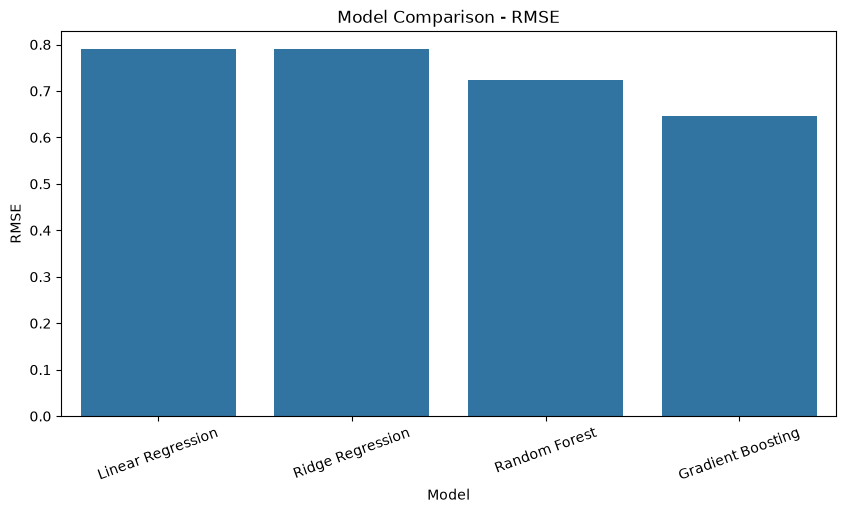

In [77]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

In [78]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [79]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [81]:
from sklearn.model_selection import GridSearchCV

In [82]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple me

In [84]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV RMSE:")
print(-grid_search.best_score_)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV RMSE:
0.64483837871193


In [85]:
final_model = grid_search.best_estimator_

In [87]:
y_pred_final = final_model.predict(x_test)

final_mae = mean_absolute_error(y_test, y_pred_final)
final_mse = mean_squared_error(y_test, y_pred_final)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, y_pred_final)

print("Final Model Performance")
print("-----------------------")
print(f"MAE  : {final_mae:.4f}")
print(f"MSE  : {final_mse:.4f}")
print(f"RMSE : {final_rmse:.4f}")
print(f"R²   : {final_r2:.4f}")

Final Model Performance
-----------------------
MAE  : 0.4789
MSE  : 0.4112
RMSE : 0.6412
R²   : 0.9865


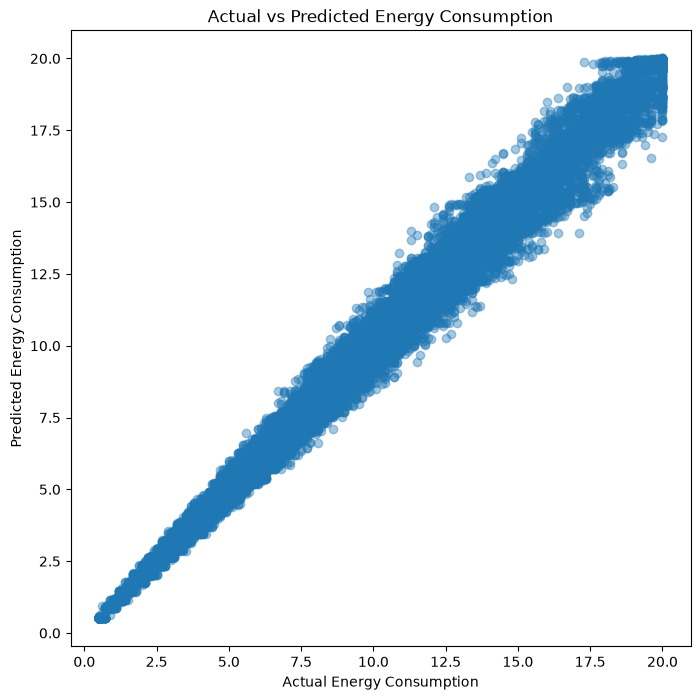

In [90]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred_final,
    alpha=0.4
)

plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")

plt.title("Actual vs Predicted Energy Consumption")

plt.show()

In [92]:
residuals = y_test - y_pred_final

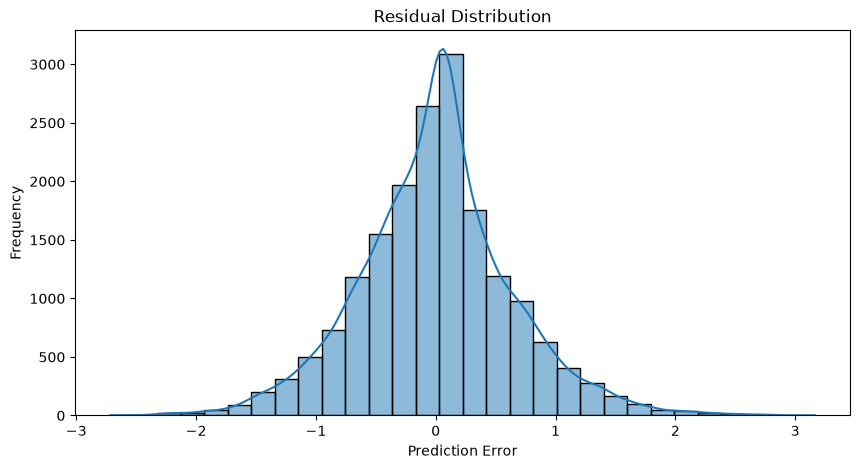

In [93]:
plt.figure(figsize=(10, 5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [96]:
joblib.dump(final_model,"household_energy_model.pkl")

['household_energy_model.pkl']

In [97]:
loaded_model = joblib.load("household_energy_model.pkl")

In [101]:
sample_prediction = loaded_model.predict(x_test.iloc[:40])

sample_prediction

array([14.8090097 ,  7.32396943, 12.32577322,  8.42965715, 16.95557836,
       10.30646623,  9.5074399 , 10.33192049, 19.13640023, 13.5940967 ,
        9.05297261,  6.75673273,  5.06242241, 14.50394663,  8.93189239,
        1.76056566, 12.7301868 ,  4.65962898, 10.83399397,  0.52155187,
        1.76198599, 15.20777951,  7.32084582, 19.79046985,  2.93254855,
       19.99211078, 12.01982322,  2.62297494, 10.86517786, 18.57153887,
        8.38982446, 14.57538316,  7.59315828, 15.77263952, 11.2622894 ,
        3.52727697,  5.67612538, 19.9700471 ,  5.64760544, 19.99918709])